In [0]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import datetime as dt
import warnings
warnings.filterwarnings('ignore')


In [0]:
# Data Preparation
data_path=('/Workspace/Users/tkndlovu111@gmail.com/Pt Readmission.csv')

df = pd.read_csv(data_path)
df.head()

,Patient ID,Age,Gender,Admission Type,Length of Stay,Number of Diagnoses,Blood Pressure,Blood Sugar Levels,Previous Admissions,Readmission
0,1,62,Female,Elective,4,5,110,130,1,No
1,2,65,Male,Emergency,19,2,157,81,4,No
2,3,82,Female,Emergency,18,4,74,84,0,No
3,4,85,Male,Emergency,2,4,106,85,4,No
4,5,85,Female,Elective,19,3,80,119,3,No


After loading the data,it is analyzed in order to understand how the data points are connected.. This is done by checking if the data is complete, confirming that each column has the correct data type, and removing any duplicate entries.

In [0]:
# Checking duplicates
df.duplicated().sum()

np.int64(0)

Analysis result- no duplicates found

In [0]:
# checking null values
df.isnull().sum()

Patient ID             0
Age                    0
Gender                 2
Admission Type         1
Length of Stay         0
Number of Diagnoses    0
Blood Pressure         0
Blood Sugar Levels     0
Previous Admissions    0
Readmission            1
dtype: int64

Analysis result-Missing values found on Gender,Admission type, Readmission

In [0]:
disctinct_values = df['Gender'].unique()
print(disctinct_values)

['Female' 'Male' nan]


In [0]:
df['Gender'].fillna('Unknown', inplace=True)

Null values in Gender repalced by Unknown

In [0]:
disctinct_values = df['Admission Type'].unique()
print(disctinct_values)

['Elective' 'Emergency' nan]


In [0]:
df['Admission Type'].fillna('Unknown', inplace=True)

Null values in Admision type repalced by Unknown

In [0]:
disctinct_values = df['Readmission'].unique()
print(disctinct_values)

['No' 'Yes' nan]


In [0]:
df['Readmission'].fillna('Unknown', inplace=True)

Null values in Reaamission repalced by Unknown

In [0]:
df.isnull().sum()

Patient ID             0
Age                    0
Gender                 0
Admission Type         0
Length of Stay         0
Number of Diagnoses    0
Blood Pressure         0
Blood Sugar Levels     0
Previous Admissions    0
Readmission            0
dtype: int64

Analysis result-All missing or null values now replaced by 'Unknown'

In [0]:
# checking for data types
df.dtypes

Patient ID              int64
Age                     int64
Gender                 object
Admission Type         object
Length of Stay          int64
Number of Diagnoses     int64
Blood Pressure          int64
Blood Sugar Levels      int64
Previous Admissions     int64
Readmission            object
dtype: object

In [0]:
# Checking for rows and columns
df.shape



(3000, 10)

In [0]:
# Count of each Admission Type
df['Admission Type'].value_counts()

Admission Type
Elective     1562
Emergency    1437
Unknown         1
Name: count, dtype: int64

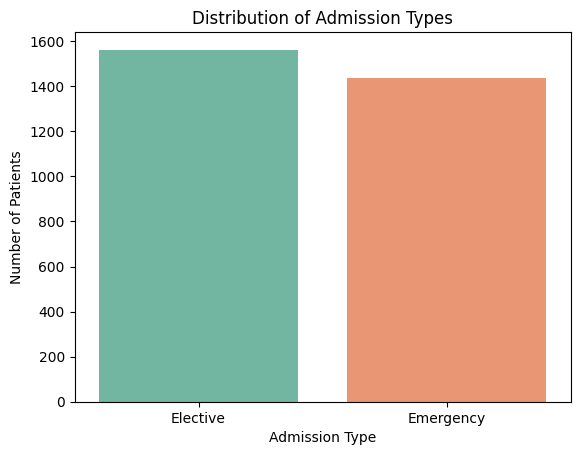

In [0]:
sns.countplot(x='Admission Type', data=df, palette='Set2')
plt.title('Distribution of Admission Types')
plt.xlabel('Admission Type')
plt.ylabel('Number of Patients')
plt.show()


Elective admissions (1562) — These are planned or scheduled hospital visits (e.g., surgeries, checkups).

Emergency admissions (1437) — These are unplanned visits, usually urgent cases (e.g., trauma, sudden illness).

In [0]:
# Count of patients by Gender
df['Gender'].value_counts()

Gender
Male       1554
Female     1444
Unknown       2
Name: count, dtype: int64

In [0]:
# Knowing the patient age from the youngest to the oldest
min_age = df['Age'].min()
max_age = df['Age'].max()
avg_age = df['Age'].mean()

print("Minimum Age:", min_age)
print("Maximum Age:", max_age)
print("Average Age:", avg_age)


Minimum Age: 18
Maximum Age: 89
Average Age: 53.453


Age Distribution Analysis:
The age of patients in the dataset ranges from 18 to 89 years, with an average age of approximately 53.5 years. This indicates that the patient population is predominantly middle-aged to older adults, although younger individuals are also represented. The wide age range suggests that the dataset captures a diverse patient demographic in terms of age.

In [0]:
# How long patients typically stay
print("Minimum Stay:", df['Length of Stay'].min())
print("Maximum Stay:", df['Length of Stay'].max())
print("Average Stay:", df['Length of Stay'].mean())

Minimum Stay: 1
Maximum Stay: 29
Average Stay: 15.226333333333333


Length of Stay Analysis:
The patients’ length of stay ranges from 1 to 29 days, with an average stay of approximately 15.2 days. This indicates that while some patients were discharged quickly, others required extended hospitalization, suggesting a wide variation in patient conditions and treatment requirements.

In [0]:
#grouped by type of admission:
df.groupby('Admission Type')['Length of Stay'].agg(['min', 'max', 'mean'])


,min,max,mean
Admission Type,,,
Elective,1,29,15.145967
Emergency,1,29,15.308977
Unknown,22,22,22.000000


Length of Stay by Admission Type:

Elective: 1–29 days, average ~15.1 days

Emergency: 1–29 days, average ~15.3 days

Unknown: 22 days

Insight: Elective and emergency admissions have similar average stays, but individual stays vary widely.

In [0]:
#How many patients were readmitted:
df['Readmission'].value_counts(normalize=True) * 100


Readmission
No         71.133333
Yes        28.833333
Unknown     0.033333
Name: proportion, dtype: float64

This indicates that most patients were not readmitted, but nearly one-third of patients experienced readmission, highlighting a notable rate of follow-up care or complications.

In [0]:
#Re by gender
df.groupby('Gender')['Readmission'].value_counts(normalize=True)


Gender   Readmission
Female   No             0.718144
         Yes            0.281163
         Unknown        0.000693
Male     No             0.705277
         Yes            0.294723
Unknown  No             0.500000
         Yes            0.500000
Name: proportion, dtype: float64

This shows that readmission rates are similar between male and female patients, with slightly higher readmission observed among males. The small number of unknown-gender cases limits interpretation for that group.

In [0]:
#Check if more diagnoses lead to longer hospital stays:
df.groupby('Number of Diagnoses', as_index=False)['Length of Stay'].mean()



,Number of Diagnoses,Length of Stay
0,1,14.270893
1,2,15.348624
2,3,14.984894
3,4,15.698864
4,5,15.125000
5,6,15.741935
6,7,15.592920
7,8,14.838806
8,9,15.498413


As the number of diagnoses increases, the average hospital stay also increases — suggesting that patients with more medical conditions tend to stay longer.

In [0]:
#Blood Pressure and Sugar Levels
#See averages and potential risk groups:
df[['Blood Pressure', 'Blood Sugar Levels']].describe()


,Blood Pressure,Blood Sugar Levels
count,3000.000000,3000.000000
mean,119.058000,133.536000
std,34.089265,37.626311
min,60.000000,51.000000
25%,89.750000,101.000000
50%,119.000000,133.000000
75%,147.250000,167.000000
max,179.000000,199.000000


75th percentile: 147 → means 25% of patients have readings above 147 → possible hypertension group.
75th percentile (167) → 25% of patients have high sugar levels, which could indicate risk of diabetes or poor glucose control.

In [0]:
#You can check if high blood pressure correlates with high blood sugar — this might show potential metabolic or diabetic risks:
df[['Blood Pressure', 'Blood Sugar Levels']].corr()


,Blood Pressure,Blood Sugar Levels
Blood Pressure,1.000000,-0.009829
Blood Sugar Levels,-0.009829,1.000000


So, a value of -0.0098 means:
➡️ There is virtually no linear relationship between Blood Pressure and Blood Sugar Levels in your dataset.
People with higher blood pressure don’t necessarily have higher or lower blood sugar levels — at least not based on this data.

In [0]:
# How many diagnoses patients have
df['Number of Diagnoses'].value_counts()

Number of Diagnoses
4    352
1    347
5    344
7    339
8    335
3    331
2    327
9    315
6    310
Name: count, dtype: int64

Insights

The most common number of diagnoses is 4 (352 patients).

The least common is 6 (310 patients), but the distribution is fairly even — meaning patients are spread across different diagnosis counts.

This shows a balanced dataset, where no single diagnosis count dominates too heavily.

In [0]:
# What is the average blood pressure?
df['Blood Pressure'].mean()

In [0]:
# What is the average blood sugar level?
df['Blood Sugar Levels'].mean()